In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
import cartopy
import matplotlib.colors as colors

In [2]:
def quatromatrix(left, bottom, right, top, ax=None, triplotkw={},tripcolorkw={}):
    if not ax: ax=plt.gca()
    n = left.shape[0]; m=left.shape[1]

    a = np.array([[0,0],[0,1],[.5,.5],[1,0],[1,1]])
    tr = np.array([[0,1,2], [0,2,3],[2,3,4],[1,2,4]])

    A = np.zeros((n*m*5,2))
    Tr = np.zeros((n*m*4,3))

    for i in range(n):
        for j in range(m):
            k = i*m+j
            A[k*5:(k+1)*5,:] = np.c_[a[:,0]+j, a[:,1]+i]
            Tr[k*4:(k+1)*4,:] = tr + k*5

    C = np.c_[ left.flatten(), bottom.flatten(), 
              right.flatten(), top.flatten()   ].flatten()

    triplot = ax.triplot(A[:,0], A[:,1], Tr, **triplotkw)
    tripcolor = ax.tripcolor(A[:,0], A[:,1], Tr, facecolors=C, **tripcolorkw)
    return tripcolor

# First regrid output of the model to match the output from the obs on the regular lat/lon grid

In [38]:
# folder_obs and folder_sim contain the maxima aggregated at different spatial scales
# folder_RL20 contains the 20-year return level estimates (obs and sim)
folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_sim = 'D:/EUROCORDEX_extremes/DATA/SIM/'
folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

# load one obs dataset on the regular 11deg grid
for spatial_scale in ['S1','S2','S3','S4']:
    # dsObs is used to regrid the models' outputs
    file_obs = f"OBS_ERA5_011EUi_1980-2022_JJA_max_scale_{spatial_scale}.nc"
    dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)
    dsObs = dsObs.cf.add_bounds(["lon","lat"])

    for model in name_models:
        for season in ["JJA","SON","DJF","MAM"]:
            for time_scale in ["1hr","3hr","6hr","12hr","24hr","72hr"]:

                # loadtxt is fast for simple numeric files
                file_RL20 = f"matrix_10yrRL_{time_scale}_{spatial_scale}_{season}_{model}.csv"
                RL20_model = np.loadtxt(folder_RL20+file_RL20, delimiter=',')

                # use simple scaling output to produce a clean xarray object
                file_model = f'{model}1980-2020_{season}_max_scale_{spatial_scale}.nc'
                dsMod = xr.load_dataset(folder_sim+file_model, engine="netcdf4", decode_timedelta=False)
                dsMod_clean = xr.Dataset(
                    data_vars={"RL": (("y", "x"), RL20_model)},
                    coords={
                        "x": dsMod.x,
                        "y": dsMod.y,
                        "lon": (("y", "x"), dsMod.lon.values),
                        "lat": (("y", "x"), dsMod.lat.values),
                    }
                )
                dsMod_clean = dsMod_clean.cf.add_bounds(["lon","lat"])

                # regrid obs
                regridder = xe.Regridder(
                    dsMod_clean, dsObs, "conservative", unmapped_to_nan=True, ignore_degenerate=True
                )
                dsMod_regrid = regridder(dsMod_clean, keep_attrs=True)
                
                # save to csv file
                x = dsMod_regrid.RL.values
                x[np.isnan(x)] = -9999
                x[x<0] = -9999
                file_RL20 = f"matrix_10yrRL_{time_scale}_{spatial_scale}_{season}_{model}_011EUi.csv"
                np.savetxt(fname=folder_RL20+file_RL20,X=x, fmt="%.2f", delimiter=',')


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect perform

# Second compare with an observational reference, here COMEPHORE for France

In [4]:
gdf = gpd.read_file("regions.geojson")
gdf['names']

0        British Isles
1    Iberian Peninsula
2               France
3           Mid-Europe
4          Scandinavia
5                 Alps
6        Mediterranean
7       Eastern Europe
Name: names, dtype: object

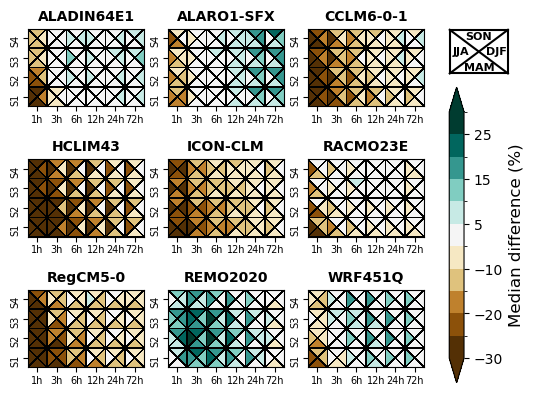

In [110]:
folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']

gdf = gpd.read_file("regions.geojson")
france_gdf = gdf.loc[gdf['names'] == 'France']

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-25,-20,-15,-10,-5,5,10,15,20,25,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, axes = plt.subplots(nrows=3,ncols=3)

for ax, model, label in zip(axes.flat, name_models, label_models):

    # initialise list
    dict_median = {}
        
    # initialise vector time/space
    vec_temporal_scale = ["1hr","3hr","6hr","12hr","24hr","72hr"]
    vec_spatial_scale = ["S1","S2","S3","S4"]

    for season in ["JJA","SON","DJF","MAM"]:
        # initiliase dict for each season
        dict_median[season] = np.zeros((len(vec_spatial_scale),len(vec_temporal_scale)))

        for itime, temporal_scale in enumerate(vec_temporal_scale):
            for ispace, spatial_scale in enumerate(vec_spatial_scale):
                # RL20 from obs
                file_RL20_obs = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_COMEPHORE_011EUi_1997-2022.csv"
                RL20_obs = np.loadtxt(fname=folder_RL20+file_RL20_obs, delimiter=',')
                RL20_obs[RL20_obs<0] = np.nan

                # RL20 from sim
                file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_{model}_011EUi.csv"
                RL20_sim = np.loadtxt(fname=folder_RL20+file_RL20_sim, delimiter=',')
                RL20_sim[RL20_sim<0] = np.nan

                # get lon/lat reg
                folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
                file_obs = f"OBS_COMEPHORE_011EUi_1997-2022_JJA_max_scale_{spatial_scale}.nc"
                dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)
                lat = dsObs.lat
                lon = dsObs.lon
                lat_2d, lon_2d = np.meshgrid(lat, lon, indexing='ij')
                lat_vec = lat_2d.flatten()
                lon_vec = lon_2d.flatten()

                # 1. Create your Points GeoDataFrame (Make sure to use EPSG:4326 for Lon/Lat)
                # Note: points_from_xy takes (longitude, latitude) -> (x, y) order
                data = {
                    'point_id': np.arange(1,len(lon_vec)+1),
                    'bias': RL20_sim.flatten() / RL20_obs.flatten() - 1,
                    'lon': lon_vec,
                    'lat': lat_vec
                }
                df_points = pd.DataFrame(data)
                gdf_points = gpd.GeoDataFrame(
                    df_points, 
                    geometry=gpd.points_from_xy(df_points.lon, df_points.lat), 
                    crs="EPSG:4326"
                )

                points_inside = gpd.sjoin(gdf_points, france_gdf, predicate='within')
                dict_median[season][ispace,itime] = np.nanmedian(points_inside.bias)*100

    
    # plot matrix
    p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

    ax.margins(0)
    ax.set_aspect("equal")

    # add label model
    ax.set_title(label, fontweight='bold', fontsize=10)

    # change the ticks and labels
    ax.set_yticks(np.arange(len(vec_spatial_scale))+0.5)
    ax.set_yticklabels(vec_spatial_scale, rotation=90, fontsize=7)
    ax.set_xticks(np.arange(len(vec_temporal_scale))+0.5)
    ax.set_xticklabels(['1h','3h','6h','12h','24h','72h'], fontsize=7)
    ax.tick_params(axis='x', pad=2)
    ax.tick_params(axis='y', pad=2)

# add colorbar
cbar = fig.colorbar(p, ax=axes, aspect=20, orientation="vertical", shrink=0.8, 
                    anchor=(0.0, 0.0), extend='both', extendfrac=0.1)
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

 # save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL20/COMEPHORE_France.png', dpi=300)

## Using EURADCLIM

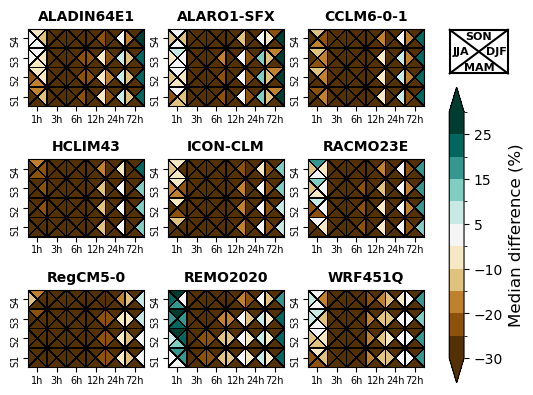

In [4]:
folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']

gdf = gpd.read_file("regions.geojson")
france_gdf = gdf.loc[gdf['names'] == 'France']

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-25,-20,-15,-10,-5,5,10,15,20,25,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, axes = plt.subplots(nrows=3,ncols=3)

for ax, model, label in zip(axes.flat, name_models, label_models):

    # initialise list
    dict_median = {}
        
    # initialise vector time/space
    vec_temporal_scale = ["1hr","3hr","6hr","12hr","24hr","72hr"]
    vec_spatial_scale = ["S1","S2","S3","S4"]

    for season in ["JJA","SON","DJF","MAM"]:
        # initiliase dict for each season
        dict_median[season] = np.zeros((len(vec_spatial_scale),len(vec_temporal_scale)))

        for itime, temporal_scale in enumerate(vec_temporal_scale):
            for ispace, spatial_scale in enumerate(vec_spatial_scale):
                # load mask
                mask = np.load(f'D:/EUROCORDEX_extremes/DATA/OBS/mask_eurad_{season}_era_{spatial_scale}.npy')
                
                # RL20 from obs
                file_RL20_obs = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_EURADCLIM_011EUi_2013-2022.csv"
                RL20_obs = np.loadtxt(fname=folder_RL20+file_RL20_obs, delimiter=',')
                RL20_obs[RL20_obs<0] = np.nan
                RL20_obs = np.where(mask, np.nan, RL20_obs) # Set values outside the range to NaN
                
                # RL20 from sim
                file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_{model}_011EUi.csv"
                RL20_sim = np.loadtxt(fname=folder_RL20+file_RL20_sim, delimiter=',')
                RL20_sim[RL20_sim<0] = np.nan
                RL20_sim = np.where(mask, np.nan, RL20_sim) # Set values outside the range to NaN
                
                # get lon/lat reg
                folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
                file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_{spatial_scale}.nc"
                dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)

                lat = dsObs.lat
                lon = dsObs.lon
                lat_2d, lon_2d = np.meshgrid(lat, lon, indexing='ij')
                lat_vec = lat_2d.flatten()
                lon_vec = lon_2d.flatten()

                # 1. Create your Points GeoDataFrame (Make sure to use EPSG:4326 for Lon/Lat)
                # Note: points_from_xy takes (longitude, latitude) -> (x, y) order
                data = {
                    'point_id': np.arange(1,len(lon_vec)+1),
                    'bias': RL20_sim.flatten() / RL20_obs.flatten() - 1,
                    'lon': lon_vec,
                    'lat': lat_vec
                }
                df_points = pd.DataFrame(data)
                gdf_points = gpd.GeoDataFrame(
                    df_points, 
                    geometry=gpd.points_from_xy(df_points.lon, df_points.lat), 
                    crs="EPSG:4326"
                )

                points_inside = gpd.sjoin(gdf_points, france_gdf, predicate='within')
                dict_median[season][ispace,itime] = np.nanmedian(points_inside.bias)*100

    
    # plot matrix
    p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

    ax.margins(0)
    ax.set_aspect("equal")

    # add label model
    ax.set_title(label, fontweight='bold', fontsize=10)

    # change the ticks and labels
    ax.set_yticks(np.arange(len(vec_spatial_scale))+0.5)
    ax.set_yticklabels(vec_spatial_scale, rotation=90, fontsize=7)
    ax.set_xticks(np.arange(len(vec_temporal_scale))+0.5)
    ax.set_xticklabels(['1h','3h','6h','12h','24h','72h'], fontsize=7)
    ax.tick_params(axis='x', pad=2)
    ax.tick_params(axis='y', pad=2)

# add colorbar
cbar = fig.colorbar(p, ax=axes, aspect=20, orientation="vertical", shrink=0.8, 
                    anchor=(0.0, 0.0), extend='both', extendfrac=0.1)
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

 # save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL20/EURADCLIM_France.png', dpi=300)

## For Italy / Mediterranean

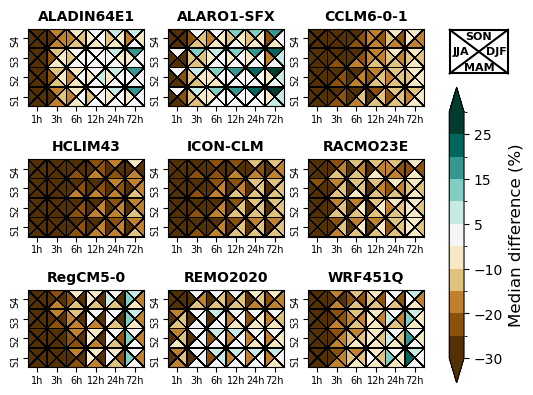

In [5]:
folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']

gdf = gpd.read_file("regions.geojson")
france_gdf = gdf.loc[gdf['names'] == 'Mediterranean']

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-25,-20,-15,-10,-5,5,10,15,20,25,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, axes = plt.subplots(nrows=3,ncols=3)

for ax, model, label in zip(axes.flat, name_models, label_models):

    # initialise list
    dict_median = {}
        
    # initialise vector time/space
    vec_temporal_scale = ["1hr","3hr","6hr","12hr","24hr","72hr"]
    vec_spatial_scale = ["S1","S2","S3","S4"]

    for season in ["JJA","SON","DJF","MAM"]:
        # initiliase dict for each season
        dict_median[season] = np.zeros((len(vec_spatial_scale),len(vec_temporal_scale)))

        for itime, temporal_scale in enumerate(vec_temporal_scale):
            for ispace, spatial_scale in enumerate(vec_spatial_scale):
                # RL20 from obs
                file_RL20_obs = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_GRIPHO_011EUi_2001-2016.csv"
                RL20_obs = np.loadtxt(fname=folder_RL20+file_RL20_obs, delimiter=',')
                RL20_obs[RL20_obs<0] = np.nan

                # RL20 from sim
                file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_{model}_011EUi.csv"
                RL20_sim = np.loadtxt(fname=folder_RL20+file_RL20_sim, delimiter=',')
                RL20_sim[RL20_sim<0] = np.nan

                # get lon/lat reg
                folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
                file_obs = f"OBS_COMEPHORE_011EUi_1997-2022_JJA_max_scale_{spatial_scale}.nc"
                dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)
                lat = dsObs.lat
                lon = dsObs.lon
                lat_2d, lon_2d = np.meshgrid(lat, lon, indexing='ij')
                lat_vec = lat_2d.flatten()
                lon_vec = lon_2d.flatten()

                # 1. Create your Points GeoDataFrame (Make sure to use EPSG:4326 for Lon/Lat)
                # Note: points_from_xy takes (longitude, latitude) -> (x, y) order
                data = {
                    'point_id': np.arange(1,len(lon_vec)+1),
                    'bias': RL20_sim.flatten() / RL20_obs.flatten() - 1,
                    'lon': lon_vec,
                    'lat': lat_vec
                }
                df_points = pd.DataFrame(data)
                gdf_points = gpd.GeoDataFrame(
                    df_points, 
                    geometry=gpd.points_from_xy(df_points.lon, df_points.lat), 
                    crs="EPSG:4326"
                )

                points_inside = gpd.sjoin(gdf_points, france_gdf, predicate='within')
                dict_median[season][ispace,itime] = np.nanmedian(points_inside.bias)*100

    
    # plot matrix
    p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

    ax.margins(0)
    ax.set_aspect("equal")

    # add label model
    ax.set_title(label, fontweight='bold', fontsize=10)

    # change the ticks and labels
    ax.set_yticks(np.arange(len(vec_spatial_scale))+0.5)
    ax.set_yticklabels(vec_spatial_scale, rotation=90, fontsize=7)
    ax.set_xticks(np.arange(len(vec_temporal_scale))+0.5)
    ax.set_xticklabels(['1h','3h','6h','12h','24h','72h'], fontsize=7)
    ax.tick_params(axis='x', pad=2)
    ax.tick_params(axis='y', pad=2)

# add colorbar
cbar = fig.colorbar(p, ax=axes, aspect=20, orientation="vertical", shrink=0.8, 
                    anchor=(0.0, 0.0), extend='both', extendfrac=0.1)
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

 # save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL20/GRIPHO_Mediterranean.png', dpi=300)

## RADKLIM / Germany

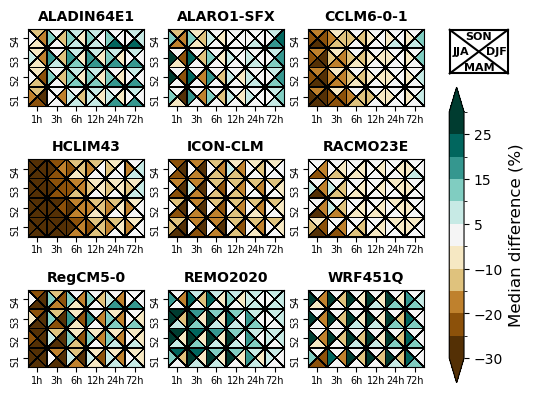

In [7]:
folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']

gdf = gpd.read_file("regions.geojson")
france_gdf = gdf.loc[gdf['names'] == 'Mid-Europe']

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-25,-20,-15,-10,-5,5,10,15,20,25,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, axes = plt.subplots(nrows=3,ncols=3)

for ax, model, label in zip(axes.flat, name_models, label_models):

    # initialise list
    dict_median = {}
        
    # initialise vector time/space
    vec_temporal_scale = ["1hr","3hr","6hr","12hr","24hr","72hr"]
    vec_spatial_scale = ["S1","S2","S3","S4"]

    for season in ["JJA","SON","DJF","MAM"]:
        # initiliase dict for each season
        dict_median[season] = np.zeros((len(vec_spatial_scale),len(vec_temporal_scale)))

        for itime, temporal_scale in enumerate(vec_temporal_scale):
            for ispace, spatial_scale in enumerate(vec_spatial_scale):
                # RL20 from obs
                file_RL20_obs = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_RADKLIM_011EUi_2001-2022.csv"
                RL20_obs = np.loadtxt(fname=folder_RL20+file_RL20_obs, delimiter=',')
                RL20_obs[RL20_obs<0] = np.nan

                # RL20 from sim
                file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_{model}_011EUi.csv"
                RL20_sim = np.loadtxt(fname=folder_RL20+file_RL20_sim, delimiter=',')
                RL20_sim[RL20_sim<0] = np.nan

                # get lon/lat reg
                folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
                file_obs = f"OBS_COMEPHORE_011EUi_1997-2022_JJA_max_scale_{spatial_scale}.nc"
                dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)
                lat = dsObs.lat
                lon = dsObs.lon
                lat_2d, lon_2d = np.meshgrid(lat, lon, indexing='ij')
                lat_vec = lat_2d.flatten()
                lon_vec = lon_2d.flatten()

                # 1. Create your Points GeoDataFrame (Make sure to use EPSG:4326 for Lon/Lat)
                # Note: points_from_xy takes (longitude, latitude) -> (x, y) order
                data = {
                    'point_id': np.arange(1,len(lon_vec)+1),
                    'bias': RL20_sim.flatten() / RL20_obs.flatten() - 1,
                    'lon': lon_vec,
                    'lat': lat_vec
                }
                df_points = pd.DataFrame(data)
                gdf_points = gpd.GeoDataFrame(
                    df_points, 
                    geometry=gpd.points_from_xy(df_points.lon, df_points.lat), 
                    crs="EPSG:4326"
                )

                points_inside = gpd.sjoin(gdf_points, france_gdf, predicate='within')
                dict_median[season][ispace,itime] = np.nanmedian(points_inside.bias)*100

    
    # plot matrix
    p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

    ax.margins(0)
    ax.set_aspect("equal")

    # add label model
    ax.set_title(label, fontweight='bold', fontsize=10)

    # change the ticks and labels
    ax.set_yticks(np.arange(len(vec_spatial_scale))+0.5)
    ax.set_yticklabels(vec_spatial_scale, rotation=90, fontsize=7)
    ax.set_xticks(np.arange(len(vec_temporal_scale))+0.5)
    ax.set_xticklabels(['1h','3h','6h','12h','24h','72h'], fontsize=7)
    ax.tick_params(axis='x', pad=2)
    ax.tick_params(axis='y', pad=2)

# add colorbar
cbar = fig.colorbar(p, ax=axes, aspect=20, orientation="vertical", shrink=0.8, 
                    anchor=(0.0, 0.0), extend='both', extendfrac=0.1)
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

 # save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL20/RADKLIM_MidEurope.png', dpi=300)